# Hyperparameter Tuning

This notebook performs hyperparameter tuning for the best models identified in Model_Building.ipynb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# Load data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = joblib.load('../dataset/train_test_regression.pkl')
X_train_cls, X_test_cls, y_train_cls, y_test_cls = joblib.load('../dataset/train_test_classification.pkl')
df_processed = pd.read_csv('../dataset/student_data_processed.csv')

print('Data loaded successfully!')
print(f'Regression: Train={X_train_reg.shape[0]}, Test={X_test_reg.shape[0]}')
print(f'Classification: Train={X_train_cls.shape[0]}, Test={X_test_cls.shape[0]}')

Data loaded successfully!
Regression: Train=8000, Test=2000
Classification: Train=8000, Test=2000


## Hyperparameter Tuning - Regression (GradientBoosting)

In [3]:
# GradientBoosting Regression - Hyperparameter Grid
gb_reg_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print('Starting GradientBoosting Regression Hyperparameter Tuning...')
print('This may take a few minutes...')

gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg_search = RandomizedSearchCV(
    gb_reg, gb_reg_params, n_iter=20, cv=3, 
    scoring='r2', n_jobs=-1, random_state=42, verbose=1
)
gb_reg_search.fit(X_train_reg, y_train_reg)

print(f'\nBest Parameters: {gb_reg_search.best_params_}')
print(f'Best CV R2: {gb_reg_search.best_score_:.4f}')

Starting GradientBoosting Regression Hyperparameter Tuning...
This may take a few minutes...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.1}
Best CV R2: 0.9743


In [4]:
# Evaluate tuned model
best_gb_reg = gb_reg_search.best_estimator_
y_pred_reg = best_gb_reg.predict(X_test_reg)

r2_tuned = r2_score(y_test_reg, y_pred_reg)
rmse_tuned = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print('Tuned GradientBoosting Regression Results:')
print(f'  R2: {r2_tuned:.4f}')
print(f'  RMSE: {rmse_tuned:.4f}')

Tuned GradientBoosting Regression Results:
  R2: 0.9740
  RMSE: 1.9524


## Hyperparameter Tuning - Classification (SVM)

In [5]:
# SVM Classification - Hyperparameter Grid
svm_cls_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

print('Starting SVM Classification Hyperparameter Tuning...')
print('This may take a few minutes...')

svm_cls = SVC(probability=True, random_state=42)
svm_cls_search = RandomizedSearchCV(
    svm_cls, svm_cls_params, n_iter=15, cv=3,
    scoring='f1', n_jobs=-1, random_state=42, verbose=1
)
svm_cls_search.fit(X_train_cls, y_train_cls)

print(f'\nBest Parameters: {svm_cls_search.best_params_}')
print(f'Best CV F1: {svm_cls_search.best_score_:.4f}')

Starting SVM Classification Hyperparameter Tuning...
This may take a few minutes...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best Parameters: {'kernel': 'linear', 'gamma': 0.1, 'C': 0.1}
Best CV F1: 0.9470


In [6]:
# Evaluate tuned model
best_svm_cls = svm_cls_search.best_estimator_
y_pred_cls = best_svm_cls.predict(X_test_cls)

acc_tuned = accuracy_score(y_test_cls, y_pred_cls)
f1_tuned = f1_score(y_test_cls, y_pred_cls)

print('Tuned SVM Classification Results:')
print(f'  Accuracy: {acc_tuned:.4f}')
print(f'  F1 Score: {f1_tuned:.4f}')

Tuned SVM Classification Results:
  Accuracy: 0.9470
  F1 Score: 0.9452


## Multi-Class Classification (Grade Category)

In [7]:
# Prepare data for multi-class classification
# Check if grade_category exists
if 'grade_category' in df_processed.columns:
    y_multi = df_processed['grade_category']
    print(f'Grade categories: {y_multi.unique()}')
    print(f'Distribution:\n{y_multi.value_counts()}')
else:
    # Create grade_category from final_exam_score if not exists
    print('Creating grade_category from final_exam_score...')
    def categorize_grade(score):
        if score >= 90: return 'A'
        elif score >= 80: return 'B'
        elif score >= 70: return 'C'
        elif score >= 60: return 'D'
        else: return 'F'
    
    y_multi = df_processed['final_exam_score'].apply(categorize_grade)
    print(f'Created grade categories: {y_multi.unique()}')
    print(f'Distribution:\n{y_multi.value_counts()}')

Grade categories: ['F' 'C' 'D' 'B' 'A']
Distribution:
grade_category
F    5172
D    3829
C     904
B      85
A      10
Name: count, dtype: int64


In [8]:
# Prepare features - exclude all non-numeric and target columns
exclude_cols = ['student_id', 'gender', 'parental_education', 'family_income', 
                'final_exam_score', 'pass_fail', 'grade_category', 'study_environment']
feature_cols = [col for col in df_processed.columns if col not in exclude_cols]
X_multi = df_processed[feature_cols].select_dtypes(include=[np.number])

# Encode target
le_grade = LabelEncoder()
y_multi_encoded = le_grade.fit_transform(y_multi)

# Split data
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi_encoded, test_size=0.2, random_state=42, stratify=y_multi_encoded
)

print(f'Multi-class Classification Data:')
print(f'  Features: {X_multi.shape[1]}')
print(f'  Train: {X_train_multi.shape[0]}')
print(f'  Test: {X_test_multi.shape[0]}')
print(f'  Classes: {le_grade.classes_}')

Multi-class Classification Data:
  Features: 30
  Train: 8000
  Test: 2000
  Classes: ['A' 'B' 'C' 'D' 'F']


In [9]:
# Train multi-class models
models_multi = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results_multi = {}

for name in models_multi:
    print(f'\nTraining {name}...')
    model = models_multi[name]
    model.fit(X_train_multi, y_train_multi)
    y_pred_multi = model.predict(X_test_multi)
    
    acc = accuracy_score(y_test_multi, y_pred_multi)
    f1 = f1_score(y_test_multi, y_pred_multi, average='weighted')
    
    results_multi[name] = {'Accuracy': acc, 'F1': f1, 'y_pred': y_pred_multi}
    print(f'  Accuracy: {acc:.4f}, F1 (weighted): {f1:.4f}')


Training LogisticRegression...
  Accuracy: 0.9890, F1 (weighted): 0.9892

Training RandomForest...
  Accuracy: 1.0000, F1 (weighted): 1.0000

Training GradientBoosting...
  Accuracy: 1.0000, F1 (weighted): 1.0000


In [10]:
# Best multi-class model
best_multi_name = max(results_multi, key=lambda x: results_multi[x]['F1'])
best_multi_model = models_multi[best_multi_name]

print(f'\nBest Multi-class Model: {best_multi_name}')
print(f'Accuracy: {results_multi[best_multi_name]["Accuracy"]:.4f}')
print(f'F1 (weighted): {results_multi[best_multi_name]["F1"]:.4f}')

# Classification report
y_pred_best = results_multi[best_multi_name]['y_pred']
print(f'\nClassification Report:')
print(classification_report(y_test_multi, y_pred_best, target_names=le_grade.classes_.astype(str)))


Best Multi-class Model: RandomForest
Accuracy: 1.0000
F1 (weighted): 1.0000

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         2
           B       1.00      1.00      1.00        17
           C       1.00      1.00      1.00       181
           D       1.00      1.00      1.00       766
           F       1.00      1.00      1.00      1034

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



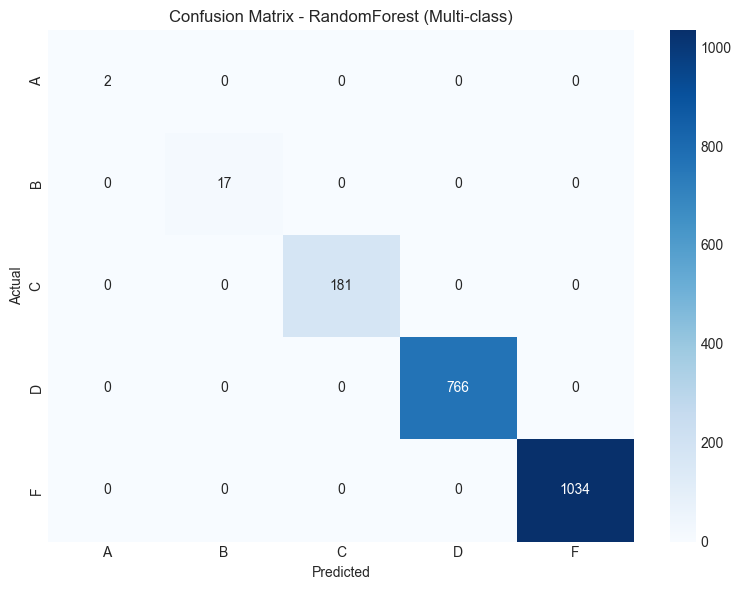

In [11]:
# Confusion matrix for multi-class
cm_multi = confusion_matrix(y_test_multi, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_grade.classes_, yticklabels=le_grade.classes_)
plt.title(f'Confusion Matrix - {best_multi_name} (Multi-class)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../docs/multiclass_confusion_matrix.png', dpi=150)
plt.show()

## Save Tuned Models

In [12]:
# Save all best models
joblib.dump(best_gb_reg, '../dataset/tuned_regression_model.pkl')
joblib.dump(best_svm_cls, '../dataset/tuned_classification_model.pkl')
joblib.dump(best_multi_model, '../dataset/best_multiclass_model.pkl')
joblib.dump(le_grade, '../dataset/grade_encoder.pkl')

print('All tuned models saved successfully!')

All tuned models saved successfully!


## Summary

In [13]:
print('='*70)
print('HYPERPARAMETER TUNING & MULTI-CLASS SUMMARY')
print('='*70)
print(f'\n1. Tuned Regression (GradientBoosting):')
print(f'   Best Params: {gb_reg_search.best_params_}')
print(f'   R2: {r2_tuned:.4f}')
print(f'\n2. Tuned Classification (SVM):')
print(f'   Best Params: {svm_cls_search.best_params_}')
print(f'   Accuracy: {acc_tuned:.4f}, F1: {f1_tuned:.4f}')
print(f'\n3. Multi-class Classification ({best_multi_name}):')
print(f'   Accuracy: {results_multi[best_multi_name]["Accuracy"]:.4f}')
print(f'   F1 (weighted): {results_multi[best_multi_name]["F1"]:.4f}')
print(f'   Classes: {list(le_grade.classes_)}')
print('='*70)

HYPERPARAMETER TUNING & MULTI-CLASS SUMMARY

1. Tuned Regression (GradientBoosting):
   Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.1}
   R2: 0.9740

2. Tuned Classification (SVM):
   Best Params: {'kernel': 'linear', 'gamma': 0.1, 'C': 0.1}
   Accuracy: 0.9470, F1: 0.9452

3. Multi-class Classification (RandomForest):
   Accuracy: 1.0000
   F1 (weighted): 1.0000
   Classes: ['A', 'B', 'C', 'D', 'F']
